In [16]:
import pandas as pd
import librosa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt  # Добавьте эту библиотеку
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import random
import os
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
from sklearn.model_selection import cross_validate
from pathlib import Path
import matplotlib.gridspec as gridspec

In [4]:
#Файлы
large_data_path = r'F:\datasets\whale-detection-challenge\whale_data\data' 
train_path = Path(large_data_path) / 'train'
test_path = Path(large_data_path) / 'test'

#Метки
train_csv_path = Path(large_data_path) / 'train.csv'
train_df = pd.read_csv(train_csv_path)

train_df = train_df.rename(columns={'clip_name_label': 'filename', 'train1.atif,0': 'label'})

train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
test_audio_files = list(test_path.rglob('*.aiff')) + list(test_path.rglob('*.aif'))

print(f"Размер датасета: {len(train_df)}")
print(f"Распределение меток:\n{train_df['label'].value_counts()}")


Размер датасета: 30000
Распределение меток:
label
0    22973
1     7027
Name: count, dtype: int64


In [5]:

def whale_denoise(y, sr, low_freq=10, high_freq=800):

    try:
        if not np.all(np.isfinite(y)):
            return y
            
        if len(y) == 0:
            return y
        
        #Bandpass
        def butter_bandpass(lowcut, highcut, fs, order=4):
            nyq = 0.5 * fs
            low = lowcut / nyq
            high = highcut / nyq
            b, a = butter(order, [low, high], btype='band')
            return b, a
        
        b, a = butter_bandpass(low_freq, high_freq, sr)
        y_filtered = filtfilt(b, a, y)
        
        if not np.all(np.isfinite(y_filtered)):
            return y
        
        #stft
        D = librosa.stft(y_filtered, n_fft=2048, hop_length=512)
        magnitude = np.abs(D)
        phase = np.angle(D)
        
        noise_frames = magnitude[:, :max(1, int(0.2 * sr / 512))]  # минимум 1 кадр
        noise_profile = np.median(noise_frames, axis=1, keepdims=True)

        noise_profile = np.maximum(noise_profile, 1e-12)
        
        threshold = 1.5 * noise_profile
        magnitude_clean = np.maximum(magnitude - threshold, 1e-12) 
        
        if not np.all(np.isfinite(magnitude_clean)):
            return y_filtered

        D_clean = magnitude_clean * np.exp(1j * phase)
        y_clean = librosa.istft(D_clean)
        
        if not np.all(np.isfinite(y_clean)):
            return y
            
        return y_clean
        
    except Exception as e:
        return y
              

In [6]:
def load_and_preprocess_audio(file_path, apply_denoise=True, target_sr=22050, duration=5):

    try:
        y, sr = librosa.load(file_path, sr=target_sr, duration=duration)

        if apply_denoise:
            y = whale_denoise(y, sr, low_freq=20, high_freq=1000)

        y = librosa.util.normalize(y)
        
        return y, sr
        
    except Exception as e:
        print(f"Ошибка загрузки файла {file_path}: {e}")
        return None, None

In [7]:
def extract_features_from_audio(y, sr, n_mfcc=20, n_mels=128):

    features = {}
    
    # MFCC 
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    
    # Mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_mean = np.mean(mel_spec, axis=1)
    mel_std = np.std(mel_spec, axis=1)
    
    # Chroma features
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_mean = np.mean(chroma, axis=1)
    chroma_std = np.std(chroma, axis=1)
    
    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    
    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y)
    
    # RMS energy
    rms = librosa.feature.rms(y=y)
    
    features['mfcc_mean'] = mfcc_mean
    features['mfcc_std'] = mfcc_std
    features['mel_mean'] = mel_mean
    features['mel_std'] = mel_std
    features['chroma_mean'] = chroma_mean
    features['chroma_std'] = chroma_std
    features['spectral_centroid'] = np.mean(spectral_centroid)
    features['spectral_bandwidth'] = np.mean(spectral_bandwidth)
    features['spectral_rolloff'] = np.mean(spectral_rolloff)
    features['zcr'] = np.mean(zcr)
    features['rms'] = np.mean(rms)
    
    feature_vector = []
    for key in features:
        if isinstance(features[key], np.ndarray):
            feature_vector.extend(features[key])
        else:
            feature_vector.append(features[key])
    
    return np.array(feature_vector)


In [8]:
def process_dataset(df, audio_files_path, apply_denoise=True, max_files=None):

    features_list = []
    labels_list = []
    failed_files = []
    
    if max_files:
        file_subset = audio_files_path[:max_files]
    else:
        file_subset = audio_files_path
    
    for i, audio_file in enumerate(file_subset):
        if i % 1000 == 0:
            print(f"{i}/{len(file_subset)}")
        
        filename = audio_file.name
        
        label_row = df[df['clip_name'] == filename]
        if label_row.empty:
            print(f"Метка не найдена для файла {filename}")
            continue
        
        label = label_row['label'].values[0]
        
        y, sr = load_and_preprocess_audio(audio_file, apply_denoise=apply_denoise)
        
        if y is not None and sr is not None:

            features = extract_features_from_audio(y, sr)
            features_list.append(features)
            labels_list.append(label)
        else:
            failed_files.append(filename)
    
    print(f"Обработка завершена. Успешно: {len(features_list)}, Ошибки: {len(failed_files)}")
    
    if failed_files:
        print(f"Файлы с ошибками: {failed_files[:10]}")
        
    return np.array(features_list), np.array(labels_list)

In [17]:
def visualize_denoise_effect(file_path):

    y_orig, sr = librosa.load(file_path, sr=22050, duration=5)
    y_orig = librosa.util.normalize(y_orig)
    
    y_denoised = whale_denoise(y_orig.copy(), sr)
    y_denoised = librosa.util.normalize(y_denoised)
    
    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    
    # 1. Временные сигналы
    axes[0, 0].plot(y_orig)
    axes[0, 0].set_title('Оригинальный сигнал')
    axes[0, 0].set_xlabel('Время (семплы)')
    axes[0, 0].set_ylabel('Амплитуда')
    
    axes[0, 1].plot(y_denoised)
    axes[0, 1].set_title('Сигнал после шумоподавления')
    axes[0, 1].set_xlabel('Время (семплы)')
    axes[0, 1].set_ylabel('Амплитуда')
    
    # 2. Спектрограммы
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='log', ax=axes[1, 0])
    axes[1, 0].set_title('Спектрограмма оригинала')
    
    D_denoised = librosa.amplitude_to_db(np.abs(librosa.stft(y_denoised)), ref=np.max)
    librosa.display.specshow(D_denoised, sr=sr, x_axis='time', y_axis='log', ax=axes[1, 1])
    axes[1, 1].set_title('Спектрограмма после шумоподавления')
    
    # 3. Спектральные центроиды
    spectral_centroid_orig = librosa.feature.spectral_centroid(y=y_orig, sr=sr)[0]
    times_orig = librosa.times_like(spectral_centroid_orig)
    
    spectral_centroid_denoised = librosa.feature.spectral_centroid(y=y_denoised, sr=sr)[0]
    times_denoised = librosa.times_like(spectral_centroid_denoised)
    
    axes[2, 0].plot(times_orig, spectral_centroid_orig, label='Спектральный центроид')
    axes[2, 0].set_title('Спектральный центроид (оригинал)')
    axes[2, 0].set_xlabel('Время (с)')
    axes[2, 0].set_ylabel('Частота (Гц)')
    
    axes[2, 1].plot(times_denoised, spectral_centroid_denoised, label='Спектральный центроид')
    axes[2, 1].set_title('Спектральный центроид (после шумоподавления)')
    axes[2, 1].set_xlabel('Время (с)')
    axes[2, 1].set_ylabel('Частота (Гц)')
    
    # 4. MFCC сравнение
    mfcc_orig = librosa.feature.mfcc(y=y_orig, sr=sr, n_mfcc=13)
    mfcc_denoised = librosa.feature.mfcc(y=y_denoised, sr=sr, n_mfcc=13)
    
    axes[3, 0].imshow(mfcc_orig, aspect='auto', origin='lower', cmap='viridis')
    axes[3, 0].set_title('MFCC (оригинал)')
    axes[3, 0].set_xlabel('Время (кадры)')
    axes[3, 0].set_ylabel('Коэффициенты MFCC')
    
    axes[3, 1].imshow(mfcc_denoised, aspect='auto', origin='lower', cmap='viridis')
    axes[3, 1].set_title('MFCC (после шумоподавления)')
    axes[3, 1].set_xlabel('Время (кадры)')
    axes[3, 1].set_ylabel('Коэффициенты MFCC')
    
    plt.tight_layout()
    plt.show()
    
    print("Сравнение метрик:")
    print(f"RMS энергии (оригинал): {np.mean(librosa.feature.rms(y=y_orig)):.4f}")
    print(f"RMS энергии (после): {np.mean(librosa.feature.rms(y=y_denoised)):.4f}")
    
    print(f"Zero Crossing Rate (оригинал): {np.mean(librosa.feature.zero_crossing_rate(y_orig)):.4f}")
    print(f"Zero Crossing Rate (после): {np.mean(librosa.feature.zero_crossing_rate(y_denoised)):.4f}")


In [46]:
TEST_MODE = False 
APPLY_DENOISE = True  

if TEST_MODE:
    num_test_files = 100

    test_files = random.sample(train_audio_files, min(num_test_files, len(train_audio_files)))
    
    features_denoised, labels_denoised = process_dataset(
        train_df, test_files, apply_denoise=True, max_files=num_test_files
    )
    
    features_original, labels_original = process_dataset(
        train_df, test_files, apply_denoise=False, max_files=num_test_files
    )
    
    print(f"\nРезультаты:")
    print(f"Признаков с шумоподавлением: {features_denoised.shape}")
    print(f"Признаков без шумоподавления: {features_original.shape}")
    
    if len(test_files) > 0:
        sample_file = test_files[0]
        print(f"\nВизуализация эффекта шумоподавления для файла: {sample_file.name}")
        visualize_denoise_effect(sample_file)
        
else:
    
    X_train, y_train = process_dataset(
        train_df, train_audio_files, apply_denoise=APPLY_DENOISE
    )
    
    # Сохранение обработанных данных
    if len(X_train) > 0 and len(y_train) > 0:
        np.save('X_train_features.npy', X_train)
        np.save('y_train_labels.npy', y_train)
        print(f"\nДанные сохранены:")
        print(f"X_train: {X_train.shape}")
        print(f"y_train: {y_train.shape}")
        

0/30000


KeyboardInterrupt: 

In [27]:
def visualize_denoise_effect(file_path):
    y_orig, sr = librosa.load(file_path, sr=22050, duration=5)
    y_orig = librosa.util.normalize(y_orig)
    
    y_denoised = whale_denoise(y_orig.copy(), sr)
    y_denoised = librosa.util.normalize(y_denoised)
    
    # Увеличиваем размер фигуры для добавления новых графиков
    fig = plt.figure(figsize=(20, 16))
    
    # Создаем сетку 5x2 вместо 4x2
    gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.4, wspace=0.3)
    
    # 1. Временные сигналы (ряд 0)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(y_orig)
    ax1.set_title('Оригинальный сигнал (временная область)')
    ax1.set_xlabel('Время (семплы)')
    ax1.set_ylabel('Амплитуда')
    ax1.grid(True, alpha=0.3)
    
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(y_denoised)
    ax2.set_title('Сигнал после шумоподавления')
    ax2.set_xlabel('Время (семплы)')
    ax2.set_ylabel('Амплитуда')
    ax2.grid(True, alpha=0.3)
    
    # 2. Обычные спектрограммы (ряд 1)
    ax3 = fig.add_subplot(gs[1, 0])
    D_orig = librosa.amplitude_to_db(np.abs(librosa.stft(y_orig)), ref=np.max)
    librosa.display.specshow(D_orig, sr=sr, x_axis='time', y_axis='log', ax=ax3, cmap='viridis')
    ax3.set_title('Спектрограмма оригинала (STFT)')
    ax3.set_xlabel('')
    
    ax4 = fig.add_subplot(gs[1, 1])
    D_denoised = librosa.amplitude_to_db(np.abs(librosa.stft(y_denoised)), ref=np.max)
    librosa.display.specshow(D_denoised, sr=sr, x_axis='time', y_axis='log', ax=ax4, cmap='viridis')
    ax4.set_title('Спектрограмма после шумоподавления')
    ax4.set_xlabel('')
    
    # 3. Mel-спектрограммы (новый ряд 2)
    ax5 = fig.add_subplot(gs[2, 0])
    # Mel-спектрограмма для оригинального сигнала
    S_orig = librosa.feature.melspectrogram(y=y_orig, sr=sr, n_mels=128, fmax=8000)
    S_db_orig = librosa.power_to_db(S_orig, ref=np.max)
    librosa.display.specshow(S_db_orig, sr=sr, x_axis='time', y_axis='mel', ax=ax5, cmap='magma')
    ax5.set_title('Mel-спектрограмма оригинала')
    ax5.set_xlabel('')
    ax5.set_ylabel('Mel-частота')
    
    ax6 = fig.add_subplot(gs[2, 1])
    # Mel-спектрограмма для очищенного сигнала
    S_denoised = librosa.feature.melspectrogram(y=y_denoised, sr=sr, n_mels=128, fmax=8000)
    S_db_denoised = librosa.power_to_db(S_denoised, ref=np.max)
    librosa.display.specshow(S_db_denoised, sr=sr, x_axis='time', y_axis='mel', ax=ax6, cmap='magma')
    ax6.set_title('Mel-спектрограмма после шумоподавления')
    ax6.set_xlabel('')
    ax6.set_ylabel('Mel-частота')
    
    # 4. Спектральные центроиды (ряд 3)
    ax7 = fig.add_subplot(gs[3, 0])
    spectral_centroid_orig = librosa.feature.spectral_centroid(y=y_orig, sr=sr)[0]
    times_orig = librosa.times_like(spectral_centroid_orig)
    ax7.plot(times_orig, spectral_centroid_orig, label='Оригинал', linewidth=2)
    ax7.set_title('Спектральный центроид')
    ax7.set_xlabel('Время (с)')
    ax7.set_ylabel('Частота (Гц)')
    ax7.grid(True, alpha=0.3)
    ax7.legend()
    
    ax8 = fig.add_subplot(gs[3, 1])
    spectral_centroid_denoised = librosa.feature.spectral_centroid(y=y_denoised, sr=sr)[0]
    times_denoised = librosa.times_like(spectral_centroid_denoised)
    ax8.plot(times_denoised, spectral_centroid_denoised, label='После очистки', linewidth=2, color='orange')
    ax8.set_title('Спектральный центроид')
    ax8.set_xlabel('Время (с)')
    ax8.set_ylabel('Частота (Гц)')
    ax8.grid(True, alpha=0.3)
    ax8.legend()
    
    # 5. MFCC сравнение (ряд 4)
    ax9 = fig.add_subplot(gs[4, 0])
    mfcc_orig = librosa.feature.mfcc(y=y_orig, sr=sr, n_mfcc=13)
    ax9.imshow(mfcc_orig, aspect='auto', origin='lower', cmap='viridis', interpolation='bilinear')
    ax9.set_title('MFCC (оригинал)')
    ax9.set_xlabel('Время (кадры)')
    ax9.set_ylabel('Коэффициенты MFCC')
    
    ax10 = fig.add_subplot(gs[4, 1])
    mfcc_denoised = librosa.feature.mfcc(y=y_denoised, sr=sr, n_mfcc=13)
    ax10.imshow(mfcc_denoised, aspect='auto', origin='lower', cmap='viridis', interpolation='bilinear')
    ax10.set_title('MFCC (после шумоподавления)')
    ax10.set_xlabel('Время (кадры)')
    ax10.set_ylabel('Коэффициенты MFCC')
    
    plt.tight_layout()
    plt.show()
    
    # Энергетические метрики
    rms_orig = np.mean(librosa.feature.rms(y=y_orig))
    rms_denoised = np.mean(librosa.feature.rms(y=y_denoised))
    print(f"\n1. RMS энергии:")
    print(f"   • Оригинал: {rms_orig:.4f}")
    print(f"   • После очистки: {rms_denoised:.4f}")
    print(f"   • Изменение: {((rms_denoised - rms_orig)/rms_orig*100):+.2f}%")
    
    # Zero Crossing Rate
    zcr_orig = np.mean(librosa.feature.zero_crossing_rate(y_orig))
    zcr_denoised = np.mean(librosa.feature.zero_crossing_rate(y_denoised))
    print(f"\n2. Zero Crossing Rate (ZCR):")
    print(f"   • Оригинал: {zcr_orig:.4f}")
    print(f"   • После очистки: {zcr_denoised:.4f}")
    print(f"   • Изменение: {((zcr_denoised - zcr_orig)/zcr_orig*100):+.2f}%")
    
    # Спектральные метрики
    spectral_flatness_orig = np.mean(librosa.feature.spectral_flatness(y=y_orig))
    spectral_flatness_denoised = np.mean(librosa.feature.spectral_flatness(y=y_denoised))
    print(f"\n3. Спектральный флатнес (Spectral Flatness):")
    print(f"   • Оригинал: {spectral_flatness_orig:.4f}")
    print(f"   • После очистки: {spectral_flatness_denoised:.4f}")
    print(f"   • Изменение: {((spectral_flatness_denoised - spectral_flatness_orig)/spectral_flatness_orig*100):+.2f}%")
    
    # Метрики для Mel-спектрограмм
    print(f"\n4. Mel-спектрограммы (средняя энергия в дБ):")
    print(f"   • Оригинал: {np.mean(S_db_orig):.2f} дБ")
    print(f"   • После очистки: {np.mean(S_db_denoised):.2f} дБ")
    print(f"   • Разница: {np.mean(S_db_denoised) - np.mean(S_db_orig):.2f} дБ")
    
    # Статистика по MFCC
    print(f"\n5. MFCC (средние значения 1-3 коэффициентов):")
    for i in range(3):
        mfcc_orig_mean = np.mean(mfcc_orig[i])
        mfcc_denoised_mean = np.mean(mfcc_denoised[i])
        print(f"   • MFCC-{i+1}: {mfcc_orig_mean:.2f} → {mfcc_denoised_mean:.2f} "
              f"(Δ = {mfcc_denoised_mean - mfcc_orig_mean:+.2f})")

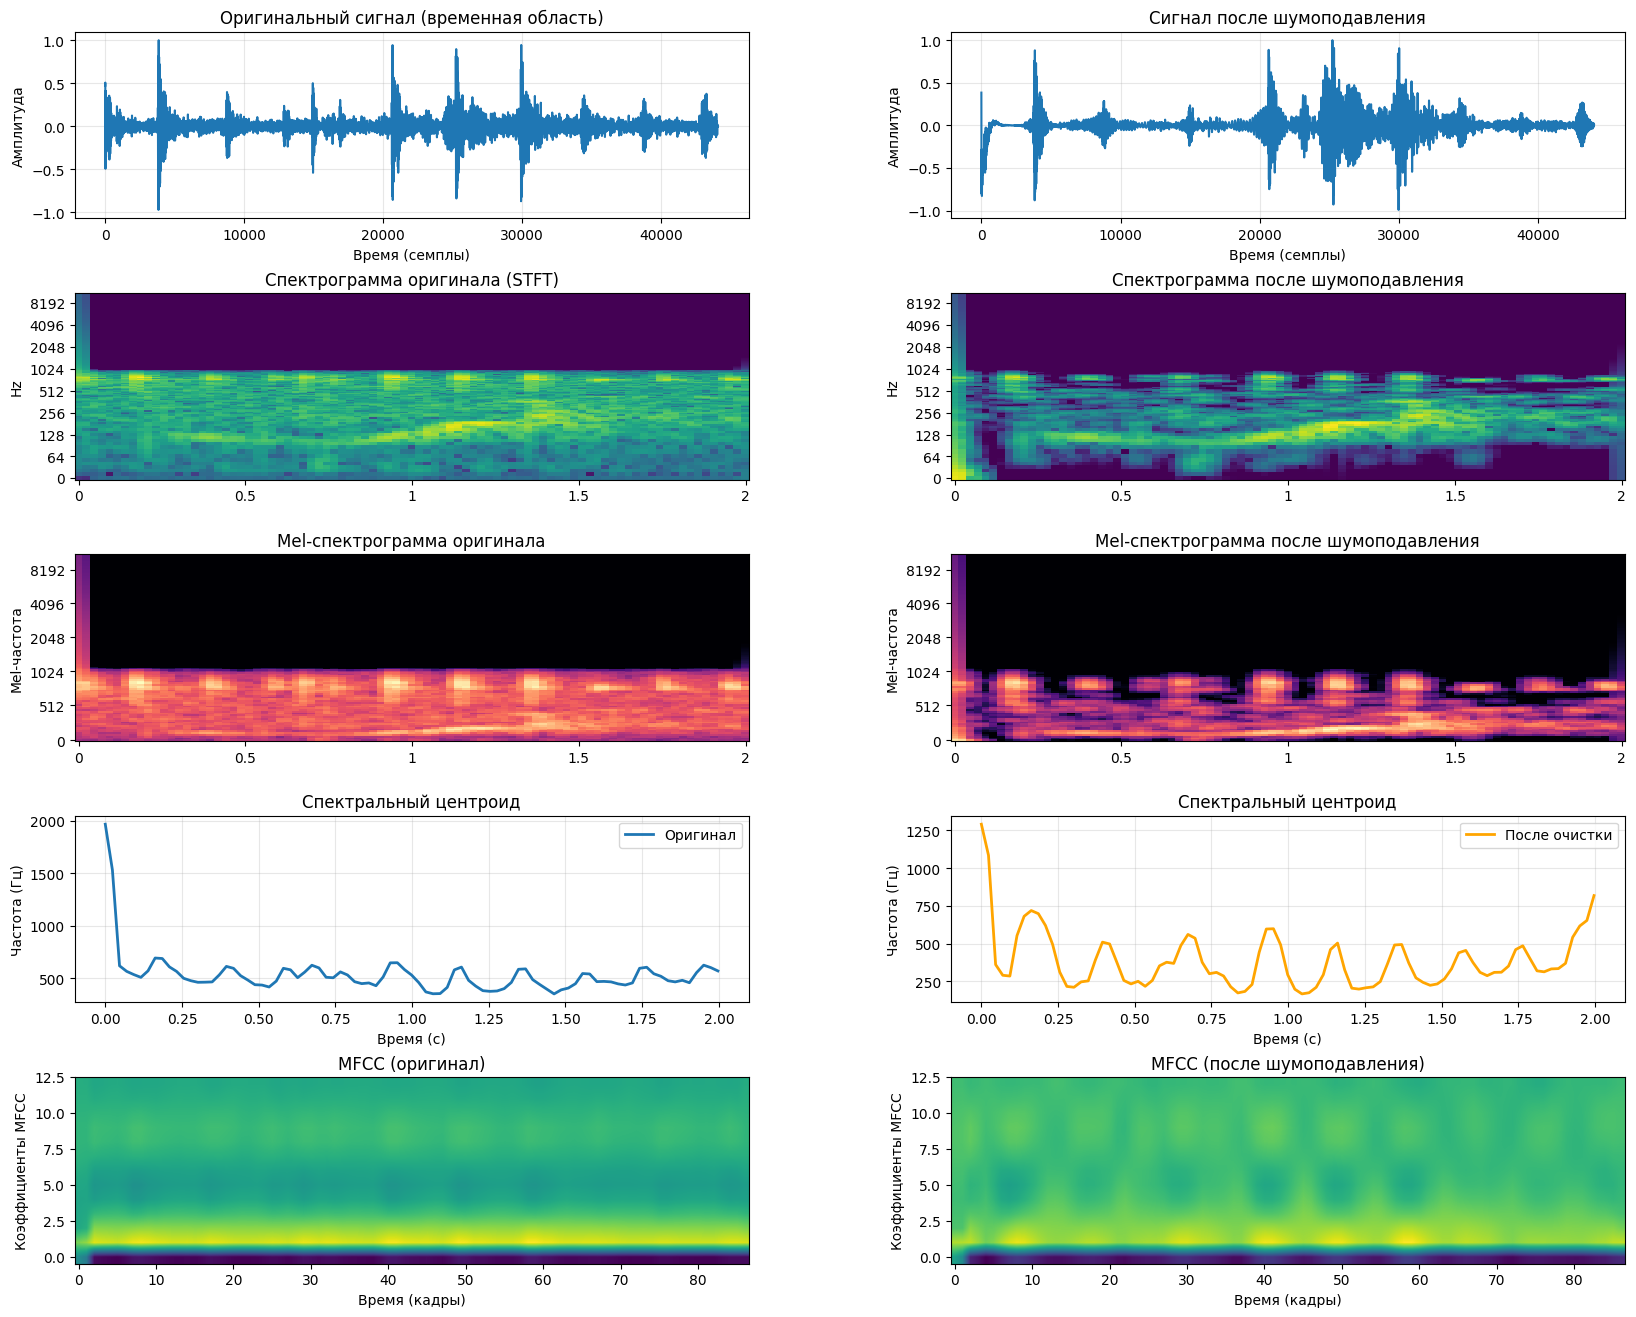


1. RMS энергии:
   • Оригинал: 0.0953
   • После очистки: 0.1065
   • Изменение: +11.77%

2. Zero Crossing Rate (ZCR):
   • Оригинал: 0.0450
   • После очистки: 0.0271
   • Изменение: -39.89%

3. Спектральный флатнес (Spectral Flatness):
   • Оригинал: 0.0002
   • После очистки: 0.0001
   • Изменение: -71.59%

4. Mel-спектрограммы (средняя энергия в дБ):
   • Оригинал: -63.04 дБ
   • После очистки: -69.39 дБ
   • Разница: -6.35 дБ

5. MFCC (средние значения 1-3 коэффициентов):
   • MFCC-1: -397.12 → -415.11 (Δ = -17.99)
   • MFCC-2: 204.44 → 133.22 (Δ = -71.22)
   • MFCC-3: 123.54 → 91.16 (Δ = -32.38)


In [45]:
visualize_denoise_effect(train_audio_files[65])

    
#if len(test_files) > 0:
#        sample_file = test_files[0]
#        print(f"\nВизуализация эффекта шумоподавления для файла: {sample_file.name}")
#        visualize_denoise_effect(sample_file)
        

In [ ]:
print(f"Количество признаков (столбцов): {len(train_df.columns)}")

print(train_df.head())

print("\nИнформация о типах данных:")
print(train_df.dtypes)

print(f"\nОписательная статистика:")
print(train_df.describe())


label_counts = train_df['label'].value_counts()
label_percentages = train_df['label'].value_counts(normalize=True) * 100


for label, count in label_counts.items():
    percentage = label_percentages[label]
    print(f"Класс {label}: {count} записей ({percentage:.2f}%)")


print(f"""
Общий размер датасета: {len(train_df)} записей
Тренировочные аудиофайлы: {len(train_audio_files)} файлов
Тестовые аудиофайлы: {len(test_audio_files)} файлов
""")

Количество признаков (столбцов): 2
     clip_name  label
0  train1.aiff      0
1  train2.aiff      0
2  train3.aiff      0
3  train4.aiff      0
4  train5.aiff      0

Информация о типах данных:
clip_name    object
label         int64
dtype: object

Описательная статистика:
              label
count  30000.000000
mean       0.234233
std        0.423526
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        1.000000
Класс 0: 22973 записей (76.58%)
Класс 1: 7027 записей (23.42%)

Общий размер датасета: 30000 записей
Тренировочные аудиофайлы: 30000 файлов
Тестовые аудиофайлы: 54503 файлов



1. Случайные спектрограммы:


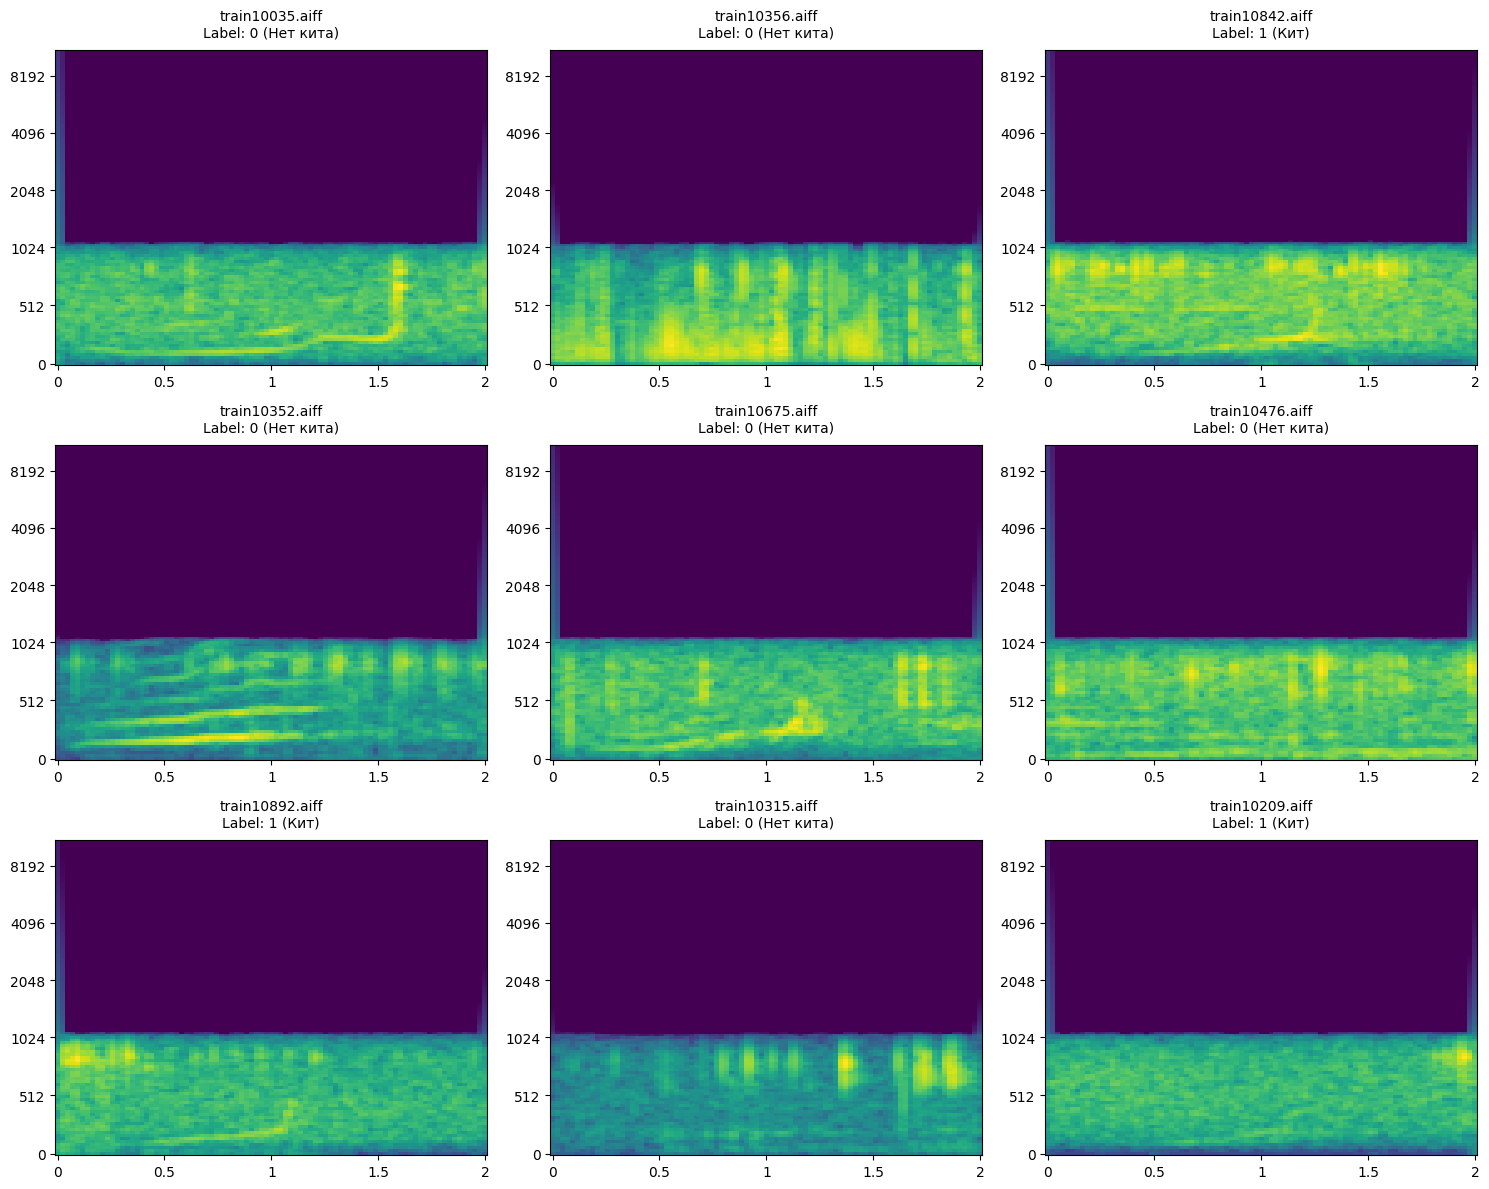

2. Сравнение спектрограмм разных классов:


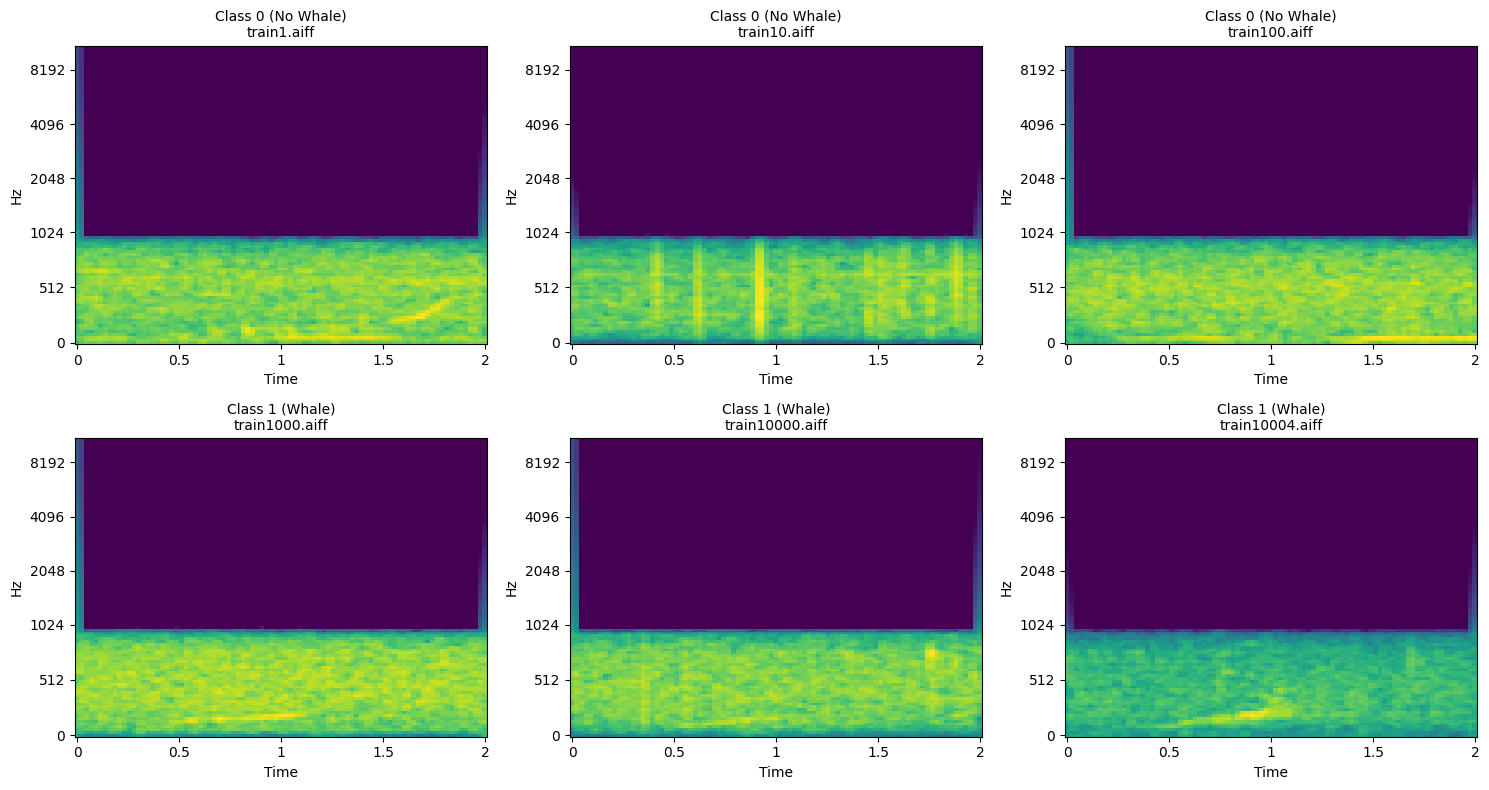

3. Анализ длительности аудиофайлов:


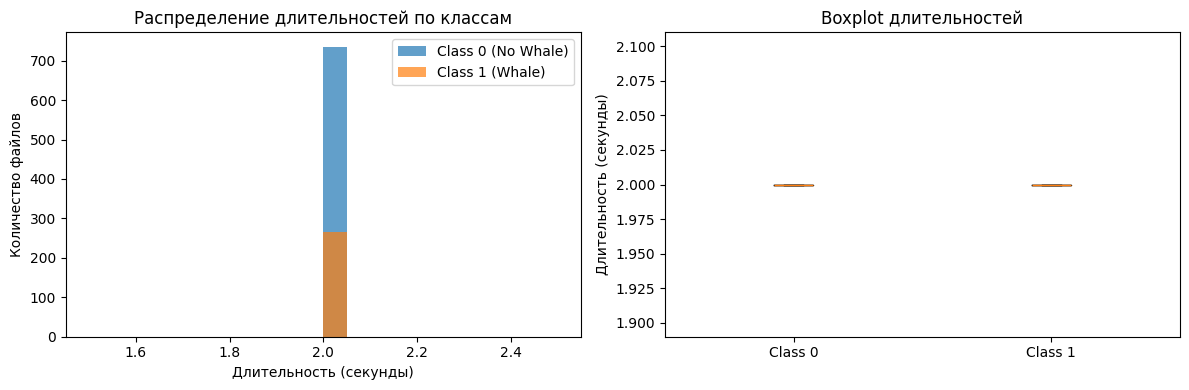

Class 0: 735 файлов, средняя длительность: 2.00 сек
Class 1: 265 файлов, средняя длительность: 2.00 сек
4. Разные типы спектрограмм для одного файла:


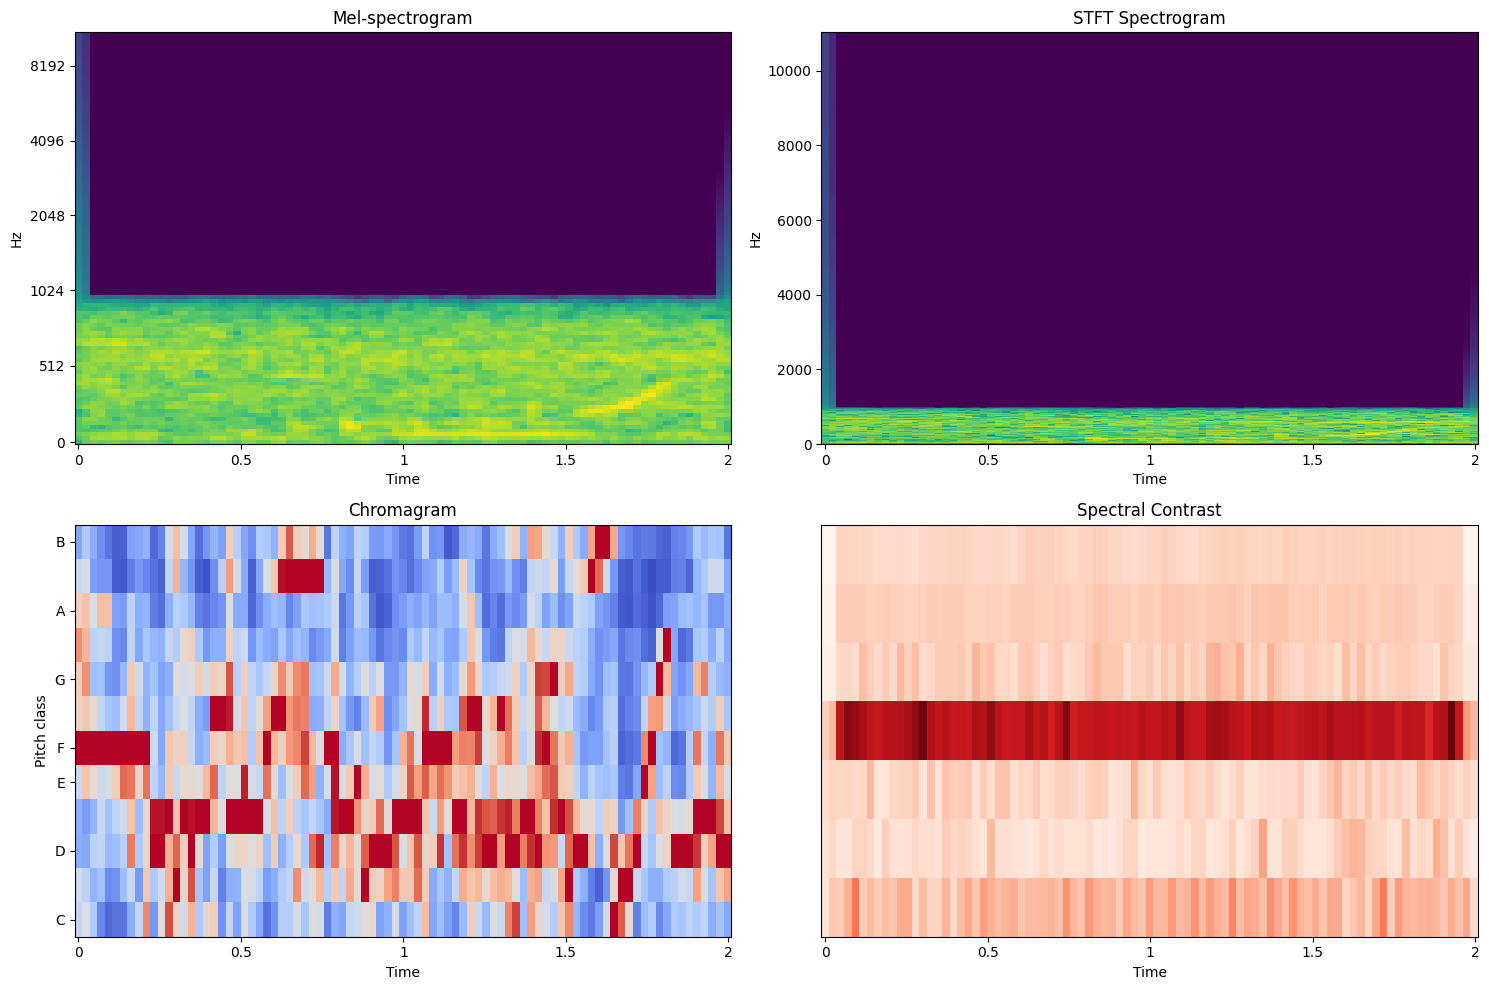

In [ ]:
#спектрограммы
def plot_random_spectrograms(audio_files, labels_df, num_samples=9, sr=22050):
    random_files = random.sample(audio_files, min(num_samples, len(audio_files)))
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes = axes.ravel()
    
    for i, audio_file in enumerate(random_files):
        try:
            y, sr = librosa.load(audio_file, sr=sr, duration=5)
            
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            label = matching_row['label'].iloc[0] if not matching_row.empty else "Unknown"

            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                                         ax=axes[i], cmap='viridis')
            
            axes[i].set_title(f'{filename}\nLabel: {label} ({"Кит" if label == 1 else "Нет кита"})', 
                            fontsize=10, pad=10)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('')
            
        except Exception as e:
            axes[i].set_title(f'Error: {audio_file.name}')
            print(f"Ошибка обработки {audio_file}: {e}")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
    return fig

def compare_classes_spectrograms(audio_files, labels_df, num_per_class=3, sr=22050):
    class_0_files = []
    class_1_files = []
    
    for audio_file in audio_files[:1000]:  
        try:
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            if not matching_row.empty:
                label = matching_row['label'].iloc[0]
                if label == 0 and len(class_0_files) < num_per_class:
                    class_0_files.append(audio_file)
                elif label == 1 and len(class_1_files) < num_per_class:
                    class_1_files.append(audio_file)
                
                if len(class_0_files) >= num_per_class and len(class_1_files) >= num_per_class:
                    break
        except:
            continue
    
    fig, axes = plt.subplots(2, num_per_class, figsize=(15, 8))
    #0 (no whale)
    for i, audio_file in enumerate(class_0_files):
        y, sr = librosa.load(audio_file, sr=sr, duration=5)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                               ax=axes[0, i], cmap='viridis')
        axes[0, i].set_title(f'Class 0 (No Whale)\n{audio_file.name}', fontsize=10)
    
    #1 (whale)
    for i, audio_file in enumerate(class_1_files):
        y, sr = librosa.load(audio_file, sr=sr, duration=5)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                               ax=axes[1, i], cmap='viridis')
        axes[1, i].set_title(f'Class 1 (Whale)\n{audio_file.name}', fontsize=10)
    
    plt.tight_layout()
    plt.show()

#длительность аудио
def audio_duration(audio_files, labels_df, max_files=1000):

    durations_0 = []
    durations_1 = []
    
    for i, audio_file in enumerate(audio_files[:max_files]):
        try:
            y, sr = librosa.load(audio_file, sr=22050)
            duration = len(y) / sr
            
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            if not matching_row.empty:
                label = matching_row['label'].iloc[0]
                if label == 0:
                    durations_0.append(duration)
                else:
                    durations_1.append(duration)
                    
        except Exception as e:
            continue
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.hist(durations_0, alpha=0.7, label='Class 0 (No Whale)', bins=20)
    plt.hist(durations_1, alpha=0.7, label='Class 1 (Whale)', bins=20)
    plt.xlabel('Длительность (секунды)')
    plt.ylabel('Количество файлов')
    plt.legend()
    plt.title('Распределение длительностей по классам')
    
    plt.subplot(1, 2, 2)
    box_data = [durations_0, durations_1]
    plt.boxplot(box_data, labels=['Class 0', 'Class 1'])
    plt.ylabel('Длительность (секунды)')
    plt.title('Boxplot длительностей')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Class 0: {len(durations_0)} файлов, средняя длительность: {np.mean(durations_0):.2f} сек")
    print(f"Class 1: {len(durations_1)} файлов, средняя длительность: {np.mean(durations_1):.2f} сек")

#разные спектрограммы для 1 файла
def plot_different_spectrogram_types(audio_file, sr=22050):
    y, sr = librosa.load(audio_file, sr=sr, duration=5)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', 
                           ax=axes[0, 0], cmap='viridis')
    axes[0, 0].set_title('Mel-spectrogram')
    
    # 2. STFT Spectrogram
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
    librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', 
                           ax=axes[0, 1], cmap='viridis')
    axes[0, 1].set_title('STFT Spectrogram')
    
    # 3. Chromagram
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    librosa.display.specshow(chroma, sr=sr, x_axis='time', y_axis='chroma', 
                           ax=axes[1, 0], cmap='coolwarm')
    axes[1, 0].set_title('Chromagram')
    
    # 4. Spectral Contrast
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    librosa.display.specshow(contrast, sr=sr, x_axis='time', 
                           ax=axes[1, 1], cmap='Reds')
    axes[1, 1].set_title('Spectral Contrast')
    
    plt.tight_layout()
    plt.show()


print("1. Случайные спектрограммы:")
fig1 = plot_random_spectrograms(train_audio_files[:1000], train_df, num_samples=9)

print("2. Сравнение спектрограмм разных классов:")
fig2 = compare_classes_spectrograms(train_audio_files[:2000], train_df, num_per_class=3)

print("3. Анализ длительности аудиофайлов:")
audio_duration(train_audio_files[:2000], train_df)

if len(train_audio_files) > 0:
    print("4. Разные типы спектрограмм для одного файла:")
    sample_file = train_audio_files[0]
    plot_different_spectrogram_types(sample_file)

In [ ]:
def extract_features(audio_files, labels_df=None, max_files=None): 
    features_data = []
    
    files_to_process = audio_files[:max_files] if max_files else audio_files
    
    for i, audio_file in enumerate(files_to_process):
        try:
            if i % 1000 == 0:
                print(f"{i}/{len(files_to_process)}")

            y, sr = librosa.load(audio_file, sr=22050, duration=10)
            
            # ЗАМЕНА MFCC НА РАСШИРЕННЫЕ ХРОМА-ПРИЗНАКИ
            chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)
            chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)                    # Хрома от постоянного Q-преобразования
            chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr)                  # CENS - энергетически нормализованная хрома
            
            # Существующие признаки
            spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)   
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y)          
            
            # ДОПОЛНИТЕЛЬНЫЕ ПРИЗНАКИ для обогащения хрома-анализа
            spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)      # Спектральный центроид
            spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)    # Спектральная ширина
            spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)        # Спектральный roll-off
            
            rms = librosa.feature.rms(y=y)                                         # RMS энергии
            tempo, _ = librosa.beat.beat_track(y=y, sr=sr)                         # Темп (для ритмических паттернов)

            label = None
            if labels_df is not None and 'label' in labels_df.columns:
                filename = audio_file.name
                matching_row = labels_df[labels_df['clip_name'] == filename]
                
                if not matching_row.empty:
                    label = matching_row['label'].iloc[0]
            
            features_data.append({
                'filename': audio_file.name,
                'filepath': str(audio_file),
                'label': label,
                'duration': len(y) / sr,
                'sample_rate': sr,
                
                # ХРОМА-ПРИЗНАКИ (основной фокус)
                'chroma_stft_mean': np.mean(chroma_stft, axis=1),                  # 12 признаков - основные хрома
                'chroma_stft_std': np.std(chroma_stft, axis=1),                    # 12 признаков - вариативность хрома
                'chroma_cqt_mean': np.mean(chroma_cqt, axis=1),                    # 12 признаков - хрома от CQT
                'chroma_cens_mean': np.mean(chroma_cens, axis=1),                  # 12 признаков - нормализованная хрома
                
                # СТАТИСТИКИ ХРОМА
                'chroma_energy_mean': np.mean(np.sum(chroma_stft, axis=0)),        # Средняя энергия хрома
                'chroma_energy_std': np.std(np.sum(chroma_stft, axis=0)),          # Стандартное отклонение энергии хрома
                'dominant_chroma': np.argmax(np.mean(chroma_stft, axis=1)),        # Доминирующий хрома-класс
                
                # СПЕКТРАЛЬНЫЕ ПРИЗНАКИ
                'spectral_contrast_mean': np.mean(spectral_contrast, axis=1),      # 7 признаков
                'spectral_centroid_mean': np.mean(spectral_centroid),              # 1 признак
                'spectral_bandwidth_mean': np.mean(spectral_bandwidth),            # 1 признак
                'spectral_rolloff_mean': np.mean(spectral_rolloff),                # 1 признак
                
                # ЭНЕРГЕТИЧЕСКИЕ И ТЕМПОРАЛЬНЫЕ ПРИЗНАКИ
                'zcr_mean': np.mean(zero_crossing_rate),                           # 1 признак
                'rms_mean': np.mean(rms),                                          # 1 признак
                'tempo': tempo,                                                    # 1 признак
                
                # ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ
                'chroma_flatness': np.mean(librosa.feature.spectral_flatness(y=y)), # Спектральная плоскость
                'chroma_crest': np.mean(librosa.feature.spectral_rolloff(y=y)),    # Спектральный crest factor
            })
            
        except Exception as e:
            print(f"Ошибка обработки {audio_file}: {e}")
            continue
            
    return pd.DataFrame(features_data)

In [ ]:
#признаки
def extract_features(audio_files, labels_df=None, max_files=None, n_mfcc_ = 13):  #n_mfcc_ = 13 - лучшее значение от test_different_mfcc_sizes
    features_data = []
    
    files_to_process = audio_files[:max_files] if max_files else audio_files
    
    for i, audio_file in enumerate(files_to_process):
        try:
            if i % 1000 == 0:
                print(f"{i}/{len(files_to_process)}")

            y, sr = librosa.load(audio_file, sr=22050, duration=10)
            
            # Аудио разбивается на фреймы по 2048 сэмплов с перекрытием 512 сэмплов
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc = n_mfcc_, n_fft=2048, hop_length=512) #создает мел спектрограмму, преобразовывает в log шкалу, потом применяет dct (по умолч n=13)
            
            chroma = librosa.feature.chroma_stft(y=y, sr=sr)                    #из спектрограммы выделяется 12 полутонов (октава)
            spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)   #контраст в 7 частотных полосах (разница пик и впадин)
            zero_crossing_rate = librosa.feature.zero_crossing_rate(y)          #частота пересечения нуля (для шума)

            label = None
            if labels_df is not None and 'label' in labels_df.columns:
                filename = audio_file.name
                matching_row = labels_df[labels_df['clip_name'] == filename]
                
                if not matching_row.empty:
                    label = matching_row['label'].iloc[0]
            
            features_data.append({
                'filename': audio_file.name,
                'filepath': str(audio_file),
                'label': label,
                'duration': len(y) / sr,
                'sample_rate': sr,                                              #частота дискретизации
                'mfcc_mean': np.mean(mfccs, axis=1),                            #средние значения Mel-Frequency Cepstral Coefficients - спектральная форма звука (средняя форма)
                'mfcc_std': np.std(mfccs, axis=1),                              #стандартные отклонения Mel-Frequency Cepstral Coefficients - спектральная форма звука (среднее отклонение)
                'chroma_mean': np.mean(chroma, axis=1),                         #Chroma Features - гармонические характеристики (тональности)
                'spectral_contrast_mean': np.mean(spectral_contrast, axis=1),   #Spectral Contrast - для различия вокализованных звуков
                'zcr_mean': np.mean(zero_crossing_rate)                         #Zero Crossing Rate - шумность сигнала
            })
            
        except Exception as e:
            print(f"Ошибка обработки {audio_file}: {e}")
            continue
            
    return pd.DataFrame(features_data)

In [ ]:
#данные
train_audio_files = list(train_path.rglob('*.aiff')) + list(train_path.rglob('*.aif'))
print(f"Найдено тренировочных файлов: {len(train_audio_files)}")

#количество для обучения
train_features_df = extract_features(train_audio_files[:20000], labels_df=train_df, max_files=20000)
#train_features_df = extract_features(train_audio_files, labels_df=train_df)

test_audio_files = list(test_path.rglob('*.aiff')) + list(test_path.rglob('*.aif'))
print(f"Найдено тестовых файлов: {len(test_audio_files)}")

#количество для теста
#test_features_df = extract_features(test_audio_files[:20000], labels_df=None, max_files=20000)
test_features_df = extract_features(test_audio_files, labels_df=None)

print(f"Обработано тренировочных файлов: {len(train_features_df)}")
print(f"Обработано тестовых файлов: {len(test_features_df)}")

Найдено тренировочных файлов: 30000
0/20000
1000/20000
2000/20000
3000/20000
4000/20000
5000/20000
6000/20000
7000/20000
8000/20000
9000/20000
10000/20000
11000/20000
12000/20000
13000/20000
14000/20000
15000/20000
16000/20000
17000/20000
18000/20000
19000/20000
Найдено тестовых файлов: 54503
0/54503
1000/54503
2000/54503
3000/54503
4000/54503
5000/54503
6000/54503
7000/54503
8000/54503
9000/54503
10000/54503
11000/54503
12000/54503
13000/54503
14000/54503
15000/54503
16000/54503
17000/54503
18000/54503
19000/54503
20000/54503
21000/54503
22000/54503
23000/54503
24000/54503
25000/54503
26000/54503
27000/54503
28000/54503
29000/54503
30000/54503
31000/54503
32000/54503
33000/54503
34000/54503
35000/54503
36000/54503
37000/54503
38000/54503
39000/54503
40000/54503
41000/54503
42000/54503
43000/54503
44000/54503
45000/54503
46000/54503
47000/54503
48000/54503
49000/54503
50000/54503
51000/54503
52000/54503
53000/54503
54000/54503
Обработано тренировочных файлов: 20000
Обработано тестовых 

In [ ]:
if len(train_features_df) > 0:
    print("\nРаспределение меток в тренировочных данных:")
    print(train_features_df['label'].value_counts())
    
    print("\nПервые 5 записей:")
    print(train_features_df[['filename', 'label', 'duration']].head())


Распределение меток в тренировочных данных:
label
0    15452
1     4548
Name: count, dtype: int64

Первые 5 записей:
          filename  label  duration
0      train1.aiff      0       2.0
1     train10.aiff      0       2.0
2    train100.aiff      0       2.0
3   train1000.aiff      1       2.0
4  train10000.aiff      1       2.0


In [ ]:
#подготовка признаков для модели
def prepare_features_for_training(features_df):
    features_list = []
    
    for _, row in features_df.iterrows():
        feature_vector = np.concatenate([
            # ХРОМА-ПРИЗНАКИ (48 признаков)
            row['chroma_stft_mean'],           # 12 признаков - основные хрома
            row['chroma_stft_std'],            # 12 признаков - вариативность хрома  
            row['chroma_cqt_mean'],            # 12 признаков - хрома от CQT
            row['chroma_cens_mean'],           # 12 признаков - нормализованная хрома
            
            # СТАТИСТИКИ ХРОМА (3 признака)
            [row['chroma_energy_mean']],       # 1 признак - средняя энергия хрома
            [row['chroma_energy_std']],        # 1 признак - станд. отклонение энергии хрома
            [row['dominant_chroma']],          # 1 признак - доминирующий хрома-класс
            
            # СПЕКТРАЛЬНЫЕ ПРИЗНАКИ (10 признаков)
            row['spectral_contrast_mean'],     # 7 признаков - спектральный контраст
            [row['spectral_centroid_mean']],   # 1 признак - спектральный центроид
            [row['spectral_bandwidth_mean']],  # 1 признак - спектральная ширина
            [row['spectral_rolloff_mean']],    # 1 признак - спектральный roll-off
            
            # ЭНЕРГЕТИЧЕСКИЕ И ТЕМПОРАЛЬНЫЕ ПРИЗНАКИ (4 признака)
            [row['zcr_mean']],                 # 1 признак - частота пересечения нуля
            [row['rms_mean']],                 # 1 признак - RMS энергии
            [row['tempo']],                    # 1 признак - темп
            [row['duration']],                 # 1 признак - длительность
            
            # ДОПОЛНИТЕЛЬНЫЕ СТАТИСТИКИ (2 признака)
            [row['chroma_flatness']],          # 1 признак - спектральная плоскость
            [row['chroma_crest']]              # 1 признак - спектральный crest factor
        ])
        features_list.append(feature_vector)
    
    return np.array(features_list)

# Применение функции
X_train = prepare_features_for_training(train_features_df)
y_train = train_features_df['label'].values

print(f"Размерность признаков: {X_train.shape}")
print(f"Общее количество признаков: {X_train.shape[1]}")
print(f"Размерность меток: {y_train.shape}")

print("\nБаланс классов:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Класс {cls}: {count} сэмплов ({count/len(y_train)*100:.1f}%)")

print("\nРаспределение признаков по группам:")
print(f"Хрома-признаки: 48 признаков")
print(f"Статистики хрома: 3 признака") 
print(f"Спектральные признаки: 10 признаков")
print(f"Энергетические и темпоральные: 4 признака")
print(f"Дополнительные статистики: 2 признака")
print(f"ИТОГО: {48 + 3 + 10 + 4 + 2} признаков")

KeyError: 'chroma_stft_mean'

In [ ]:
# Функция извлечения признаков из аудиофайла
def extract_features_from_audio(y, sr, apply_denoise=True):
    """
    Извлечение признаков из аудиосигнала
    """
    features = {}
    
    # Применение шумоподавления
    if apply_denoise:
        y = whale_denoise(y, sr)
    
    # Хрома-признаки
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_stft_mean'] = np.mean(chroma_stft, axis=1)
    features['chroma_stft_std'] = np.std(chroma_stft, axis=1)
    
    chroma_cqt = librosa.feature.chroma_cqt(y=y, sr=sr)
    features['chroma_cqt_mean'] = np.mean(chroma_cqt, axis=1)
    
    chroma_cens = librosa.feature.chroma_cens(y=y, sr=sr)
    features['chroma_cens_mean'] = np.mean(chroma_cens, axis=1)
    
    # Статистики хрома
    chroma_energy = np.sum(chroma_stft, axis=0)
    features['chroma_energy_mean'] = np.mean(chroma_energy)
    features['chroma_energy_std'] = np.std(chroma_energy)
    features['dominant_chroma'] = np.argmax(np.mean(chroma_stft, axis=1))
    
    # Спектральные признаки
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    features['spectral_contrast_mean'] = np.mean(spectral_contrast, axis=1)
    
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['spectral_centroid_mean'] = np.mean(spectral_centroid)
    
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
    
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
    
    # Энергетические и темпоральные признаки
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = np.mean(zcr)
    
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = np.mean(rms)
    
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = tempo[0] if len(tempo) > 0 else 0
    
    features['duration'] = len(y) / sr
    
    # Дополнительные статистики
    spectral_flatness = librosa.feature.spectral_flatness(y=y)
    features['chroma_flatness'] = np.mean(spectral_flatness)
    
    spectral_crest = librosa.feature.spectral_flatness(y=y)
    features['chroma_crest'] = np.mean(spectral_crest)
    
    return features

# Функция создания DataFrame с признаками
def create_features_dataframe(audio_files, labels_df, max_files=100, apply_denoise=True):
    """
    Создание DataFrame с признаками из аудиофайлов
    """
    features_list = []
    
    for i, audio_file in enumerate(audio_files[:max_files]):
        if i % 10 == 0:
            print(f"Обработано {i}/{min(max_files, len(audio_files))} файлов")
        
        try:
            # Загрузка аудио
            y, sr = librosa.load(audio_file, sr=22050, duration=5)
            
            # Извлечение признаков
            features = extract_features_from_audio(y, sr, apply_denoise=apply_denoise)
            
            # Добавление метки
            filename = audio_file.name
            matching_row = labels_df[labels_df['clip_name'] == filename]
            if not matching_row.empty:
                features['label'] = matching_row['label'].iloc[0]
                features['filename'] = filename
                features_list.append(features)
                
        except Exception as e:
            print(f"Ошибка обработки {audio_file.name}: {e}")
            continue
    
    # Создание DataFrame
    features_df = pd.DataFrame(features_list)
    return features_df

In [ ]:
#подготовка признаков для модели
def prepare_features_for_training(features_df):

    features_list = []
    
    for _, row in features_df.iterrows():
        feature_vector = np.concatenate([
            row['mfcc_mean'],               # 13 признаков
            row['mfcc_std'],                # 13 признаков  
            row['chroma_mean'],             # 12 признаков
            row['spectral_contrast_mean'],  # 7 признаков
            [row['zcr_mean']]               # 1 признак
        ])
        features_list.append(feature_vector)
    
    return np.array(features_list)

X_train = prepare_features_for_training(train_features_df)
y_train = train_features_df['label'].values

print(f"Размерность признаков: {X_train.shape}")
print(f"Размерность меток: {y_train.shape}")

print("\nБаланс классов:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Класс {cls}: {count} сэмплы ({count/len(y_train)*100:.1f}%)")

Размерность признаков: (20000, 46)
Размерность меток: (20000,)

Баланс классов:
Класс 0: 15452 сэмплы (77.3%)
Класс 1: 4548 сэмплы (22.7%)


In [ ]:
#поиск подходящего n_mfcc количества признаков
def test_different_mfcc_sizes(audio_files, labels_df, max_files=100):
    
    results = {}
    
    for n_mfcc in [5, 13, 20, 40]:
        features_df = extract_features(audio_files[:max_files], labels_df, n_mfcc)

        X = prepare_features_for_training(features_df)
        y = features_df['label'].values  
        
        model = RandomForestClassifier(n_estimators=50, random_state=42) #выбирается на деревьях
        scores = cross_val_score(model, X, y, cv=3, scoring='accuracy')
        
        results[n_mfcc] = np.mean(scores)
    
    return results
results = test_different_mfcc_sizes(train_audio_files, train_df, max_files=100)

n_mfcc_values = list(results.keys())
    
if isinstance(list(results.values())[0], dict):
    accuracies = [results[n]['accuracy'] for n in n_mfcc_values]
    stds = [results[n].get('std', 0) for n in n_mfcc_values]
    n_features = [results[n].get('n_features', 0) for n in n_mfcc_values]
else:
    accuracies = [results[n] for n in n_mfcc_values]
    stds = [0] * len(n_mfcc_values)
    n_features = [n * 2 + 20 for n in n_mfcc_values] 
    

best_acc = 0
best_n = None
print("n_mfcc | Accuracy")
for n in n_mfcc_values:
    if isinstance(results[n], dict):
        acc = results[n]['accuracy']
    else:
        acc = results[n]
    if acc > best_acc:
        best_acc = acc
        best_n = n
    print(f"{n:6} | {acc:.4f}")
print("Best n_mfcc: ", best_n)

0/5
0/13
0/20
0/40
n_mfcc | Accuracy
     5 | 0.6667
    13 | 0.8500
    20 | 0.6984
    40 | 0.7509
Best n_mfcc:  13


In [ ]:
#масштабирование признаков (уравнивание значений)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print(f"Среднее после масштабирования: {np.mean(X_train_scaled, axis=0)[:5]}...")
print(f"Стд. отклонение после масштабирования: {np.std(X_train_scaled, axis=0)[:5]}...")

Среднее после масштабирования: [-1.83064675e-16 -5.42849099e-16 -8.02030664e-16 -3.11561887e-16
 -6.56782961e-16]...
Стд. отклонение после масштабирования: [1. 1. 1. 1. 1.]...


In [ ]:
#разделение данных
X_temp, X_val, y_temp, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print("Разделение данных:")
print(f"Тренировочные: {X_temp.shape}, Валидационные: {X_val.shape}")

Разделение данных:
Тренировочные: (16000, 46), Валидационные: (4000, 46)


In [ ]:
#выбор воспроизводимости
best_score = 0
best_rs = None

for random_state in [0, 1, 42, 123, 456, 789, 999]:
    model = RandomForestClassifier(random_state=random_state, n_estimators=50) #выбирается на деревьях
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    mean_score = np.mean(scores)
    
    print(f"random_state={random_state}: {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_rs = random_state

print(f"\nЛучший: {best_rs} (score: {best_score:.4f})")

random_state=0: 0.8515
random_state=1: 0.8531
random_state=42: 0.8501
random_state=123: 0.8503
random_state=456: 0.8520
random_state=789: 0.8496
random_state=999: 0.8508

Лучший: 1 (score: 0.8531)


In [ ]:
#модели
X_temp_scaled = scaler.transform(X_temp)
X_val_scaled = scaler.transform(X_val)

models = {
    'Random Forest': RandomForestClassifier(    
        n_estimators=100,
        max_depth=10,
        random_state=best_rs,
        class_weight='balanced'
    ),
    'Logistic Regression': LogisticRegression(  # Если связь между признаками и метками относительно линейная
        random_state=best_rs, 
        class_weight='balanced',
        max_iter=1000
    ),
    'SVM': SVC(                                 #для нелинейных связей (ядер)
        random_state=best_rs, 
        class_weight='balanced',
        probability=True
    ),
    'XGBoost': XGBClassifier(                   #ансамбль деревьев с исправлением ошибок предыдущего дерева
        random_state=best_rs, 
        eval_metric='logloss',
        scale_pos_weight=len(y_temp[y_temp==0]) / len(y_temp[y_temp==1])  
    )
}


In [ ]:
#сравнение по кросс валидации
print("Сравнение моделей с помощью кросс-валидации:")
best_cv_score = 0
best_cv_model = None
best_cv_model_name = ""

cv_scores_dict = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_temp_scaled, y_temp, cv=5, scoring='accuracy')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    cv_scores_dict[name] = cv_scores
    
    print(f"{name}: {cv_mean:.4f} (+/- {cv_std * 2:.4f})")
    
    if cv_mean > best_cv_score:
        best_cv_score = cv_mean
        best_cv_model = model
        best_cv_model_name = name

print(f"\nЛучшая: {best_cv_model_name} с точностью {best_cv_score:.4f}")

Сравнение моделей с помощью кросс-валидации:
Random Forest: 0.8369 (+/- 0.0131)
Logistic Regression: 0.7969 (+/- 0.0113)
SVM: 0.6738 (+/- 0.0172)
XGBoost: 0.8605 (+/- 0.0116)

Лучшая: XGBoost с точностью 0.8605


In [ ]:
# Обучение всех моделей
trained_models = {}

for name, model in models.items():
    model.fit(X_temp_scaled, y_temp)
    trained_models[name] = model
    print(f"{name} обучена")


Random Forest обучена
Logistic Regression обучена
SVM обучена
XGBoost обучена



Сравнение моделей на валидационной выборке:

Random Forest:
  Accuracy: 0.8353
  F1-score: 0.8431

Logistic Regression:
  Accuracy: 0.7975
  F1-score: 0.8107

SVM:
  Accuracy: 0.6783
  F1-score: 0.7042

XGBoost:
  Accuracy: 0.8660
  F1-score: 0.8690

Финальная лучшая модель: XGBoost
F1-score на валидации: 0.8690

Лучшая модель: (XGBoost):
Accuracy: 0.8660

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      3090
           1       0.68      0.78      0.72       910

    accuracy                           0.87      4000
   macro avg       0.81      0.83      0.82      4000
weighted avg       0.87      0.87      0.87      4000


Confusion Matrix:


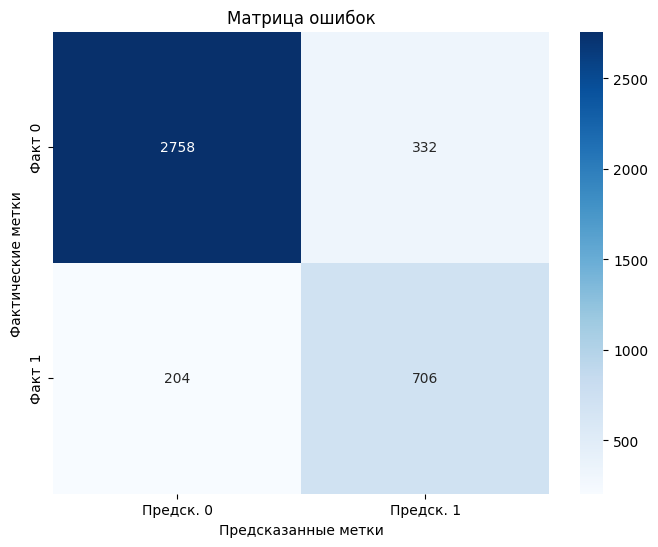

In [ ]:
# Сравниваем модели на валидационной выборке
print("\nСравнение моделей на валидационной выборке:")
best_val_score = 0
best_model = None
best_model_name = ""

val_results = {}

for name, model in trained_models.items():
    y_val_pred = model.predict(X_val_scaled)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)
    
    val_results[name] = {
        'accuracy': val_accuracy,
        'f1': val_f1
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy: {val_accuracy:.4f}")
    print(f"  F1-score: {val_f1:.4f}")
    
    # Выбираем лучшую модель по F1-score 
    if val_f1 > best_val_score:
        best_val_score = val_f1
        best_model = model
        best_model_name = name

print(f"\nФинальная лучшая модель: {best_model_name}")
print(f"F1-score на валидации: {best_val_score:.4f}")


print(f"\nЛучшая модель: ({best_model_name}):")
y_val_pred_best = best_model.predict(X_val_scaled)

print(f"Accuracy: {accuracy_score(y_val, y_val_pred_best):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_best))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Предск. 0', 'Предск. 1'],
            yticklabels=['Факт 0', 'Факт 1'])
plt.title('Матрица ошибок')
plt.ylabel('Фактические метки')
plt.xlabel('Предсказанные метки')
plt.show()
#для вывода
#accuracy - точность (общая доля)

#классификация
#precision - точность  
#recall - полнота 
#f1 score - баланс точности и полноты
#support - количество сэмплов каждого класса

#macro avg - Среднее арифметическое по всем классам, где каждый класс имеет одинаковый вес, независимо от его размера.
#weighted avg - Среднее значение, где каждый класс имеет вес, пропорциональный его размеру в датасете.

#матрица ошибок
# TN FP
# FN TP


Анализ важности признаков для XGBoost:

15 важных признаков:
                feature  importance
10         mfcc_mean_10    0.271306
43  spectral_contrast_5    0.083691
38  spectral_contrast_0    0.039821
14           mfcc_std_1    0.038046
0           mfcc_mean_0    0.036201
39  spectral_contrast_1    0.026610
44  spectral_contrast_6    0.023857
2           mfcc_mean_2    0.020355
23          mfcc_std_10    0.020301
3           mfcc_mean_3    0.019614
6           mfcc_mean_6    0.019228
7           mfcc_mean_7    0.018009
45             zcr_mean    0.014827
20           mfcc_std_7    0.014114
34             chroma_8    0.013907


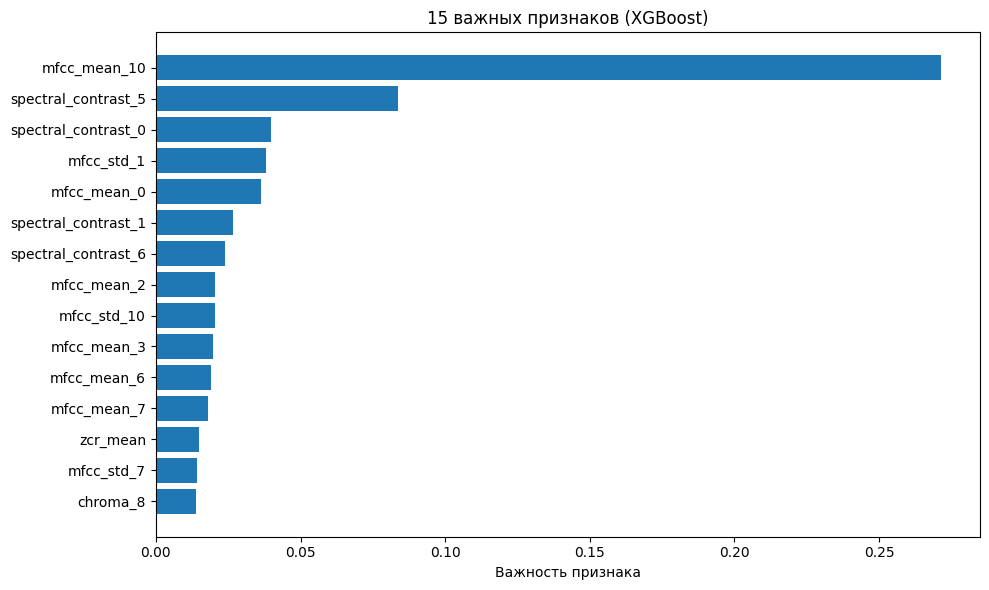

In [ ]:
# Важность признаков для деревьев
if best_model_name in ['Random Forest', 'XGBoost']:
    print(f"\nАнализ важности признаков для {best_model_name}:")
    
    if best_model_name == 'Random Forest':
        feature_importance = best_model.feature_importances_
    else:  # XGBoost
        feature_importance = best_model.feature_importances_
    
    feature_names = (
        [f'mfcc_mean_{i}' for i in range(13)] +
        [f'mfcc_std_{i}' for i in range(13)] +
        [f'chroma_{i}' for i in range(12)] +
        [f'spectral_contrast_{i}' for i in range(7)] +
        ['zcr_mean']
    )
    
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': feature_importance
    }).sort_values('importance', ascending=False)
    
    print("\n15 важных признаков:")
    print(importance_df.head(15))
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['feature'].head(15)[::-1], importance_df['importance'].head(15)[::-1])
    plt.xlabel('Важность признака')
    plt.title(f'15 важных признаков ({best_model_name})')
    plt.tight_layout()
    plt.show()

In [ ]:
# Предсказания на тестовых данных (лучшая модель)
if len(test_features_df) > 0:
    X_test = prepare_features_for_training(test_features_df)
    X_test_scaled = scaler.transform(X_test) 
    

    test_predictions = best_model.predict(X_test_scaled)
    
    test_features_df['predicted_label'] = test_predictions
    
    print(f"\nПредсказания для тестовых данных ({len(test_features_df)} файлов) ({best_model_name}):")
    print(test_features_df[['filename', 'predicted_label']].head(10))

    test_features_df[['filename', 'predicted_label']].to_csv('test_predictions.csv', index=False)
    print("Предсказания сохранены в test_predictions.csv")


Предсказания для тестовых данных (54503 файлов) (XGBoost):
         filename  predicted_label
0      test1.aiff                0
1     test10.aiff                0
2    test100.aiff                0
3   test1000.aiff                0
4  test10000.aiff                0
5  test10001.aiff                0
6  test10002.aiff                0
7  test10003.aiff                0
8  test10004.aiff                0
9  test10005.aiff                0
Предсказания сохранены в test_predictions.csv


In [ ]:
# Сохранение лучшей модели и scaler
model_filename = f'whale_detection_model_{best_model_name.lower().replace(" ", "_")}.pkl'
joblib.dump(best_model, model_filename)
joblib.dump(scaler, 'feature_scaler.pkl')

print(f"\nМодель и scaler сохранены:")
print(f"- {model_filename} ({best_model_name})")
print("- feature_scaler.pkl")


Модель и scaler сохранены:
- whale_detection_model_xgboost.pkl (XGBoost)
- feature_scaler.pkl


In [ ]:
# информация о сравнении моделей
comparison_df = pd.DataFrame({
    'Model': list(val_results.keys()),
    'CV_Accuracy': [cv_scores_dict[name].mean() for name in val_results.keys()],
    'CV_Std': [cv_scores_dict[name].std() for name in val_results.keys()],
    'Val_Accuracy': [val_results[name]['accuracy'] for name in val_results.keys()],
    'Val_F1': [val_results[name]['f1'] for name in val_results.keys()]
})

print("\nСводная таблица сравнения моделей:")
print(comparison_df.sort_values('Val_F1', ascending=False))

comparison_df.to_csv('model_comparison_results.csv', index=False)
print("Результаты сравнения моделей сохранены в model_comparison_results.csv")


Сводная таблица сравнения моделей:
                 Model  CV_Accuracy    CV_Std  Val_Accuracy    Val_F1
3              XGBoost     0.860500  0.005791       0.86600  0.868985
0        Random Forest     0.836875  0.006558       0.83525  0.843123
1  Logistic Regression     0.796938  0.005671       0.79750  0.810698
2                  SVM     0.673750  0.008581       0.67825  0.704234
Результаты сравнения моделей сохранены в model_comparison_results.csv
